# Exploratory Data Analysis (EDA)

This section explores the cleaned dataset to better understand the distribution of financial variables and their relationship with potential financial statement fraud.

The objectives of the exploratory analysis are:

- Understand the distribution of fraud observations.
- Examine how fraud rates change across years.
- Analyze the distribution of financial ratios.
- Identify relationships between variables.
- Detect features that may be informative for fraud detection.

These insights will guide the feature selection and modeling stages.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\PC\OneDrive - National Economics University\Máy tính\Fraud-Detection


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from src.config import PROCESSED_DATA_DIR
from src.features import (
    load_processed_data,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
df = load_processed_data(PROCESSED_DATA_DIR / "processed_data.xlsx")

print("Shape:", df.shape)
display(df.head())

Shape: (1906, 32)


,CP,Năm,DSRI,GMI,AQI,SGI,DEPI,SGAI,LVGI,TATA,...,Receivables_to_Revenue,Receivables_to_Assets,Inventory_to_Assets,Current_Assets_to_Total_Assets,CFO_to_Assets,CFO_to_Revenue,Accruals_to_Assets,Working_Capital_to_Assets,Firm_Size,Fraud
0,VGI,2018,1.084421,1.046653,1.029731,0.886654,0.884559,0.959822,0.889766,-0.101945,...,0.413736,0.120602,0.061870,0.397922,0.083650,0.286968,-0.101945,0.090983,31.689111,1
1,AGM,2018,1.097927,1.008271,1.340456,0.919842,0.788457,1.078348,0.633748,-0.142846,...,0.027918,0.104887,0.493065,0.732636,0.192490,0.051235,-0.142846,0.426104,27.036548,0
2,BKC,2018,0.841932,0.952255,1.080715,0.987486,0.537917,0.965435,1.197318,0.088754,...,0.128463,0.078563,0.413480,0.504713,-0.119212,-0.194930,0.088754,-0.005270,26.411455,0
3,VGS,2018,0.743001,0.993651,1.622708,1.157163,1.588574,0.717813,0.847319,-0.175852,...,0.087645,0.427095,0.266418,0.713469,0.207064,0.042492,-0.175852,0.156610,27.981720,0
4,VNG,2018,1.183387,1.019476,0.904722,0.993112,0.958951,1.122113,1.145842,-0.036049,...,0.514868,0.255890,0.006239,0.311328,0.061342,0.123425,-0.036049,0.096571,28.246052,0


## Fraud Distribution

We first examine the overall distribution of the target variable `Fraud`.

The dataset contains both fraudulent and non-fraudulent observations. Understanding this distribution is important because fraud detection problems are often characterized by **class imbalance**, which may affect model performance.

In [5]:
print("Columns:")
display(df.columns)

print("\nFraud rate:")
print(df["Fraud"].mean())

Columns:


Index(['CP', 'Năm', 'DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'LVGI',
       'TATA', 'RSST_Accruals', 'Delta_Receivables', 'Delta_Inventory',
       'Delta_ROA', 'Soft_Assets', 'ROA', 'ROE', 'Net_Profit_Margin',
       'Gross_Profit_Margin', 'Revenue_Growth', 'Debt_to_Assets',
       'Debt_to_Equity', 'Receivables_to_Revenue', 'Receivables_to_Assets',
       'Inventory_to_Assets', 'Current_Assets_to_Total_Assets',
       'CFO_to_Assets', 'CFO_to_Revenue', 'Accruals_to_Assets',
       'Working_Capital_to_Assets', 'Firm_Size', 'Fraud'],
      dtype='object')


Fraud rate:
0.28226652675760755


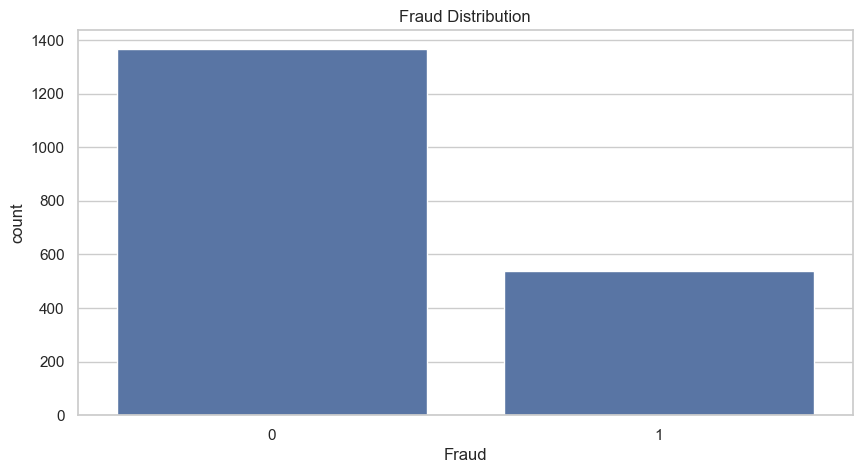

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Fraud")

plt.title("Fraud Distribution")
plt.show()

The dataset shows a moderate class imbalance where non-fraud observations dominate the dataset. 
However, the proportion of fraud cases is still substantial, which provides sufficient signal for machine learning models to learn meaningful patterns.

## Fraud Rate by Year

To understand temporal patterns in fraudulent reporting, we examine the fraud rate across years.

This analysis helps determine whether fraud occurrences vary significantly over time and whether certain periods exhibit higher levels of financial manipulation.

,fraud_rate,n_obs
Năm,,
2018,0.289116,294
2019,0.325949,316
2020,0.266667,315
2021,0.249221,321
2022,0.287009,331
2023,0.276596,329


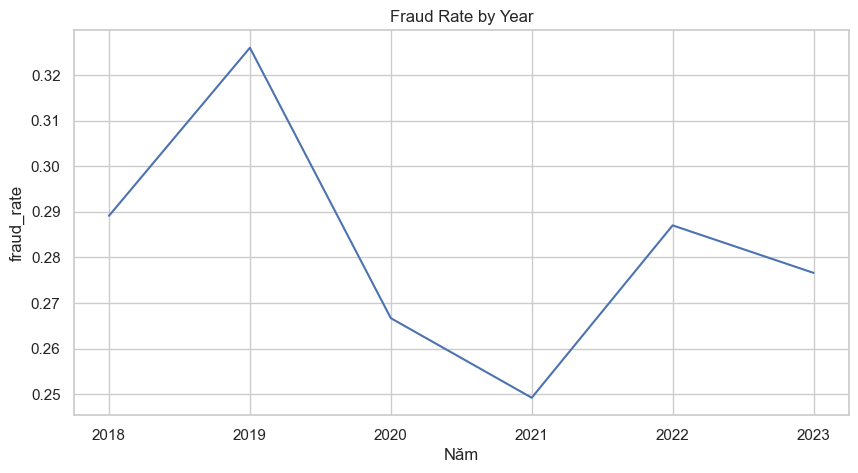

In [7]:
fraud_by_year = df.groupby("Năm")["Fraud"].agg(
    fraud_rate="mean",
    n_obs="count"
)

display(fraud_by_year)

sns.lineplot(data=fraud_by_year, x=fraud_by_year.index, y="fraud_rate")

plt.title("Fraud Rate by Year")
plt.show()

The fraud rate fluctuates across years but remains relatively stable overall. 
A slight increase is observed around certain years, which may reflect changes in market conditions, regulatory enforcement, or economic pressures affecting firms.

## Distribution of Financial Ratios

We visualize the distribution of financial variables using histograms.

Financial ratios often exhibit skewed distributions due to the nature of accounting data and firm heterogeneity. 
Understanding these distributions helps identify skewness, extreme values, and potential transformation needs before modeling.

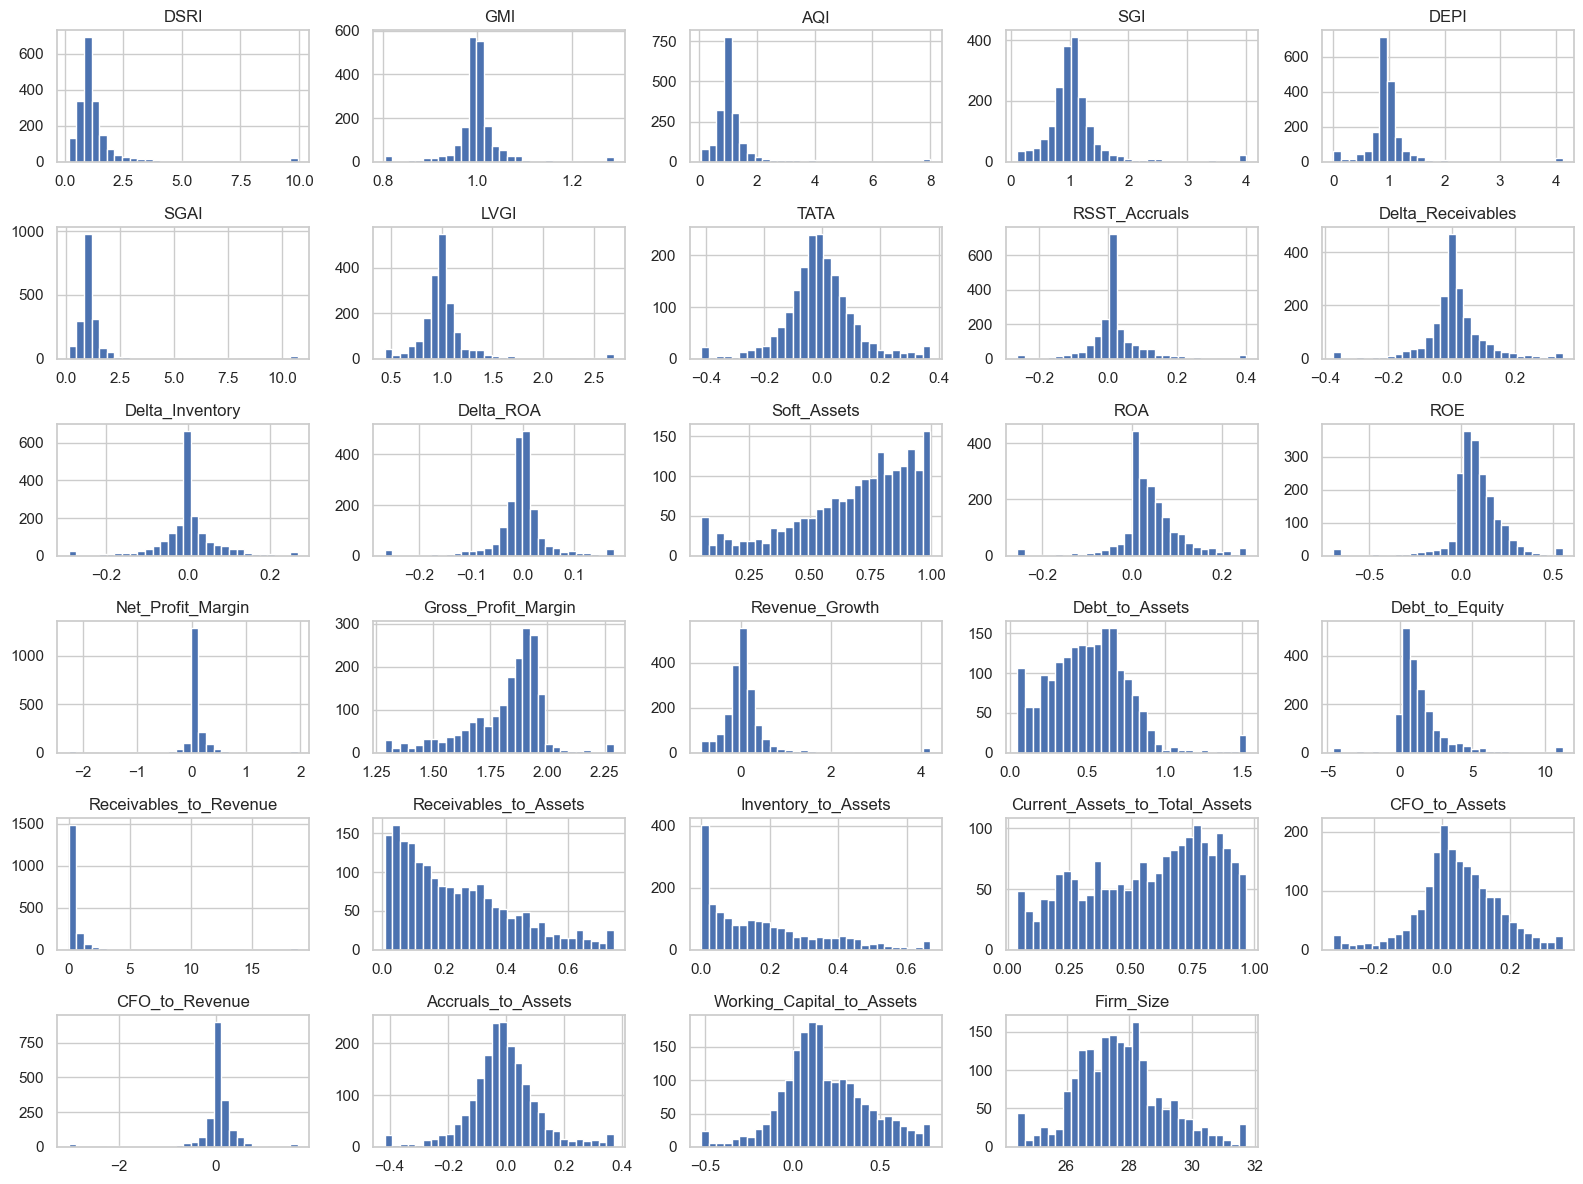

In [8]:
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols = numeric_cols.drop(["Fraud", "Năm"])

df[numeric_cols].hist(
    figsize=(16,12),
    bins=30
)

plt.tight_layout()
plt.show()

Several financial variables display skewed distributions with heavy tails. 
This is common in accounting data where firm characteristics vary substantially across industries and firm sizes.

Extreme values are not removed during EDA because they may represent potential signals of financial manipulation.

## Correlation Analysis

A correlation heatmap is used to explore relationships between financial variables.

Correlation analysis helps identify:

- Variables that move together
- Potential multicollinearity
- Structural relationships among financial indicators

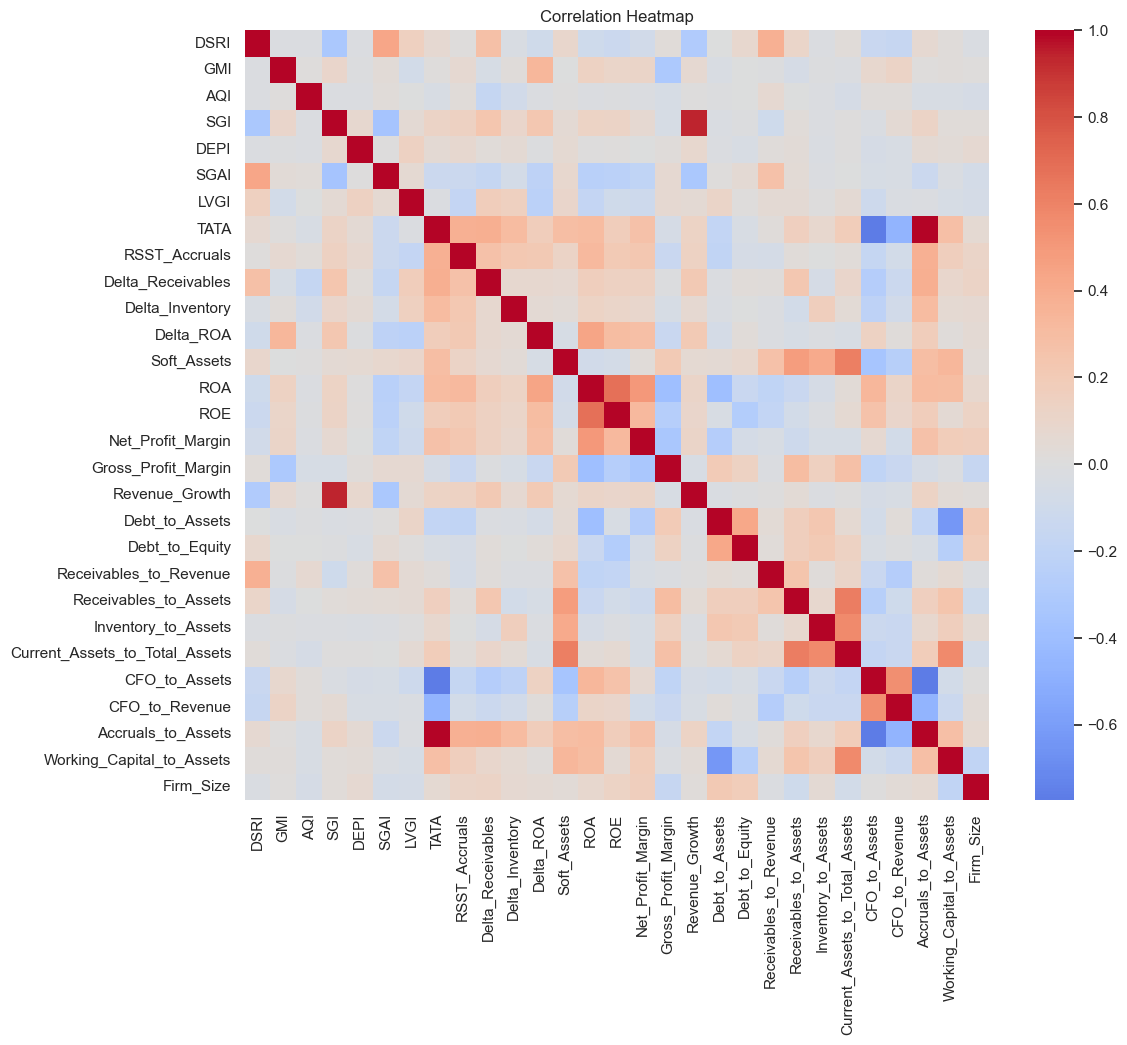

In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap reveals several moderate correlations between profitability ratios, leverage measures, and cash flow indicators.

These relationships are expected given the accounting structure of financial statements. 
However, strong multicollinearity may affect certain models and should be considered during feature selection.

## Correlation with Fraud

To identify potential fraud indicators, we examine the correlation between each financial variable and the target variable `Fraud`.

Although correlation only captures linear relationships, it provides an initial indication of which variables may be associated with fraudulent reporting.

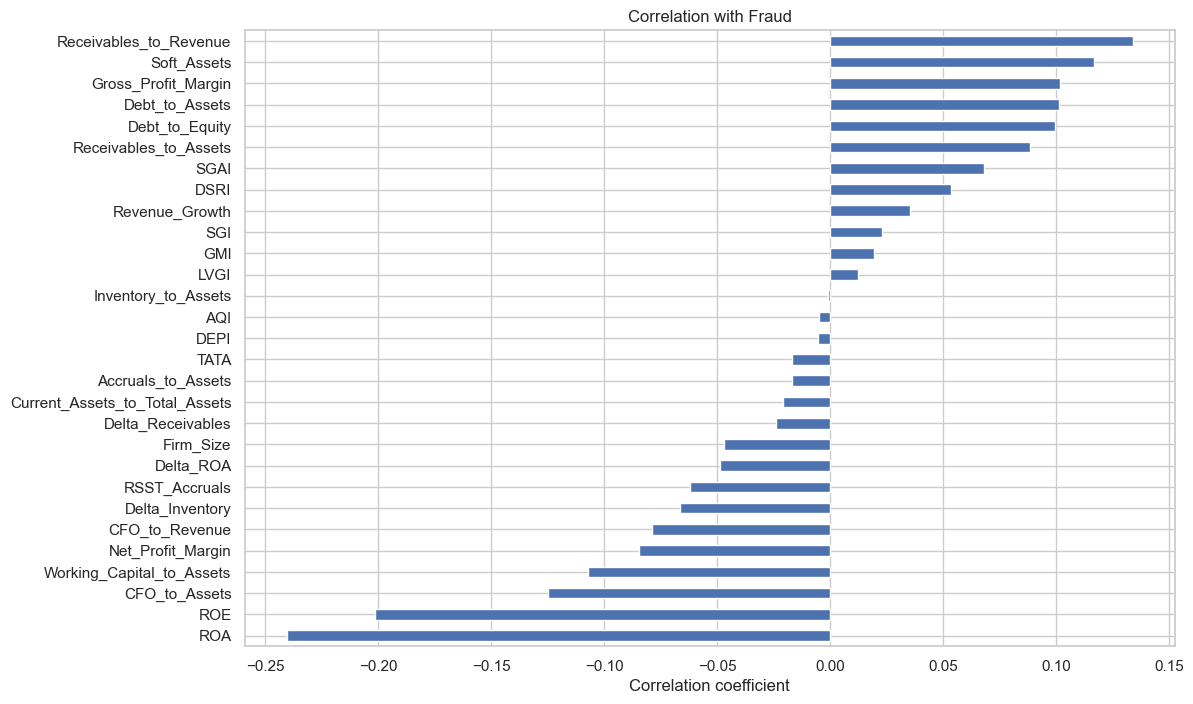

In [10]:
corr_with_fraud = df[numeric_cols].corrwith(df["Fraud"]).sort_values()

plt.figure(figsize=(12,8))
corr_with_fraud.plot(kind="barh")

plt.title("Correlation with Fraud")
plt.xlabel("Correlation coefficient")
plt.show()

The results suggest that variables related to receivables and asset composition show positive correlations with fraud. 
These variables may indicate aggressive revenue recognition or manipulation of receivable accounts.

Conversely, profitability and cash flow indicators such as ROA, ROE, and cash-flow-based ratios exhibit negative correlations with fraud, suggesting that financially weaker firms may have stronger incentives to manipulate financial statements.

## Mutual Information

While correlation captures linear relationships, mutual information which helps identify features that may carry predictive information about fraudulent behavior even when the relationship is not strictly linear. measures both linear and non-linear dependencies between variables and the target.


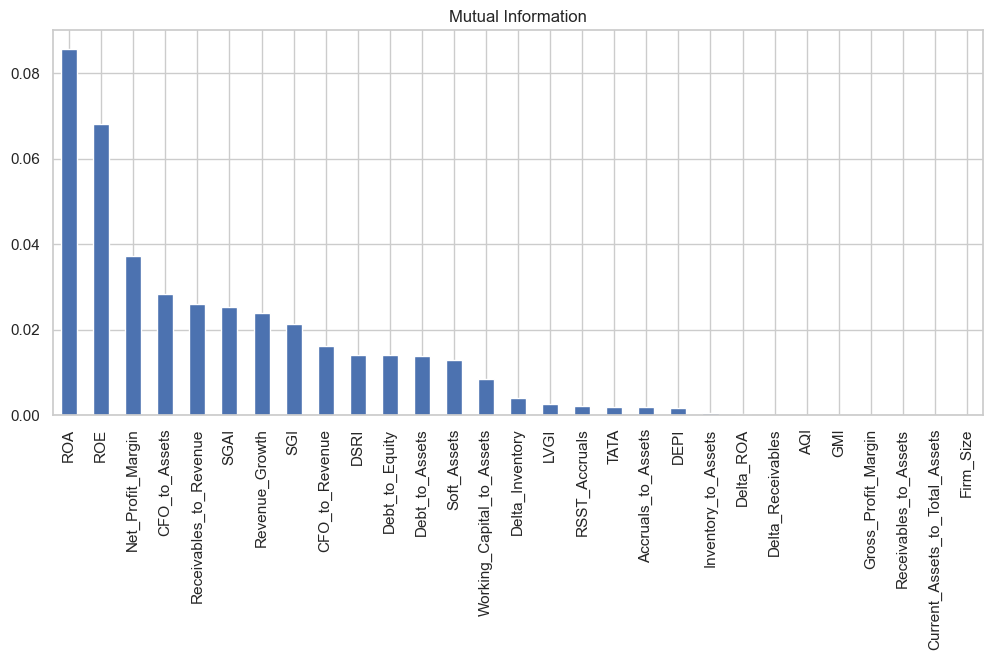

In [11]:
from sklearn.feature_selection import mutual_info_classif

X = df[numeric_cols]
y = df["Fraud"]

mi = mutual_info_classif(X, y)

mi_df = pd.Series(mi, index=numeric_cols).sort_values(ascending=False)

plt.figure(figsize=(12,5))
mi_df.plot(kind="bar")
plt.title("Mutual Information")
plt.show()

Mutual information results highlight profitability indicators such as ROA and ROE as the most informative variables for predicting fraud.

Other variables related to revenue growth, receivables, and leverage also provide meaningful predictive signals. 
These findings suggest that financial performance, asset structure, and revenue dynamics play important roles in identifying potentially fraudulent firms.

## Comparison Between Fraud and Non-Fraud Firms

To better understand the financial characteristics associated with fraudulent firms, we compare the distributions of several key financial ratios between fraud and non-fraud observations.

The following boxplots illustrate how important financial indicators differ across the two groups. These indicators include:

- Profitability measures (ROA, ROE, Net Profit Margin)
- Cash flow quality indicators (CFO to Assets, CFO to Revenue)
- Asset structure variables (Soft Assets, Receivables)
- Leverage measures (Debt to Assets, Debt to Equity)
- Working capital and operational ratios

Top features by absolute correlation with Fraud:
['ROA', 'ROE', 'Receivables_to_Revenue', 'CFO_to_Assets', 'Soft_Assets', 'Working_Capital_to_Assets', 'Gross_Profit_Margin', 'Debt_to_Assets', 'Debt_to_Equity', 'Receivables_to_Assets', 'Net_Profit_Margin', 'CFO_to_Revenue']


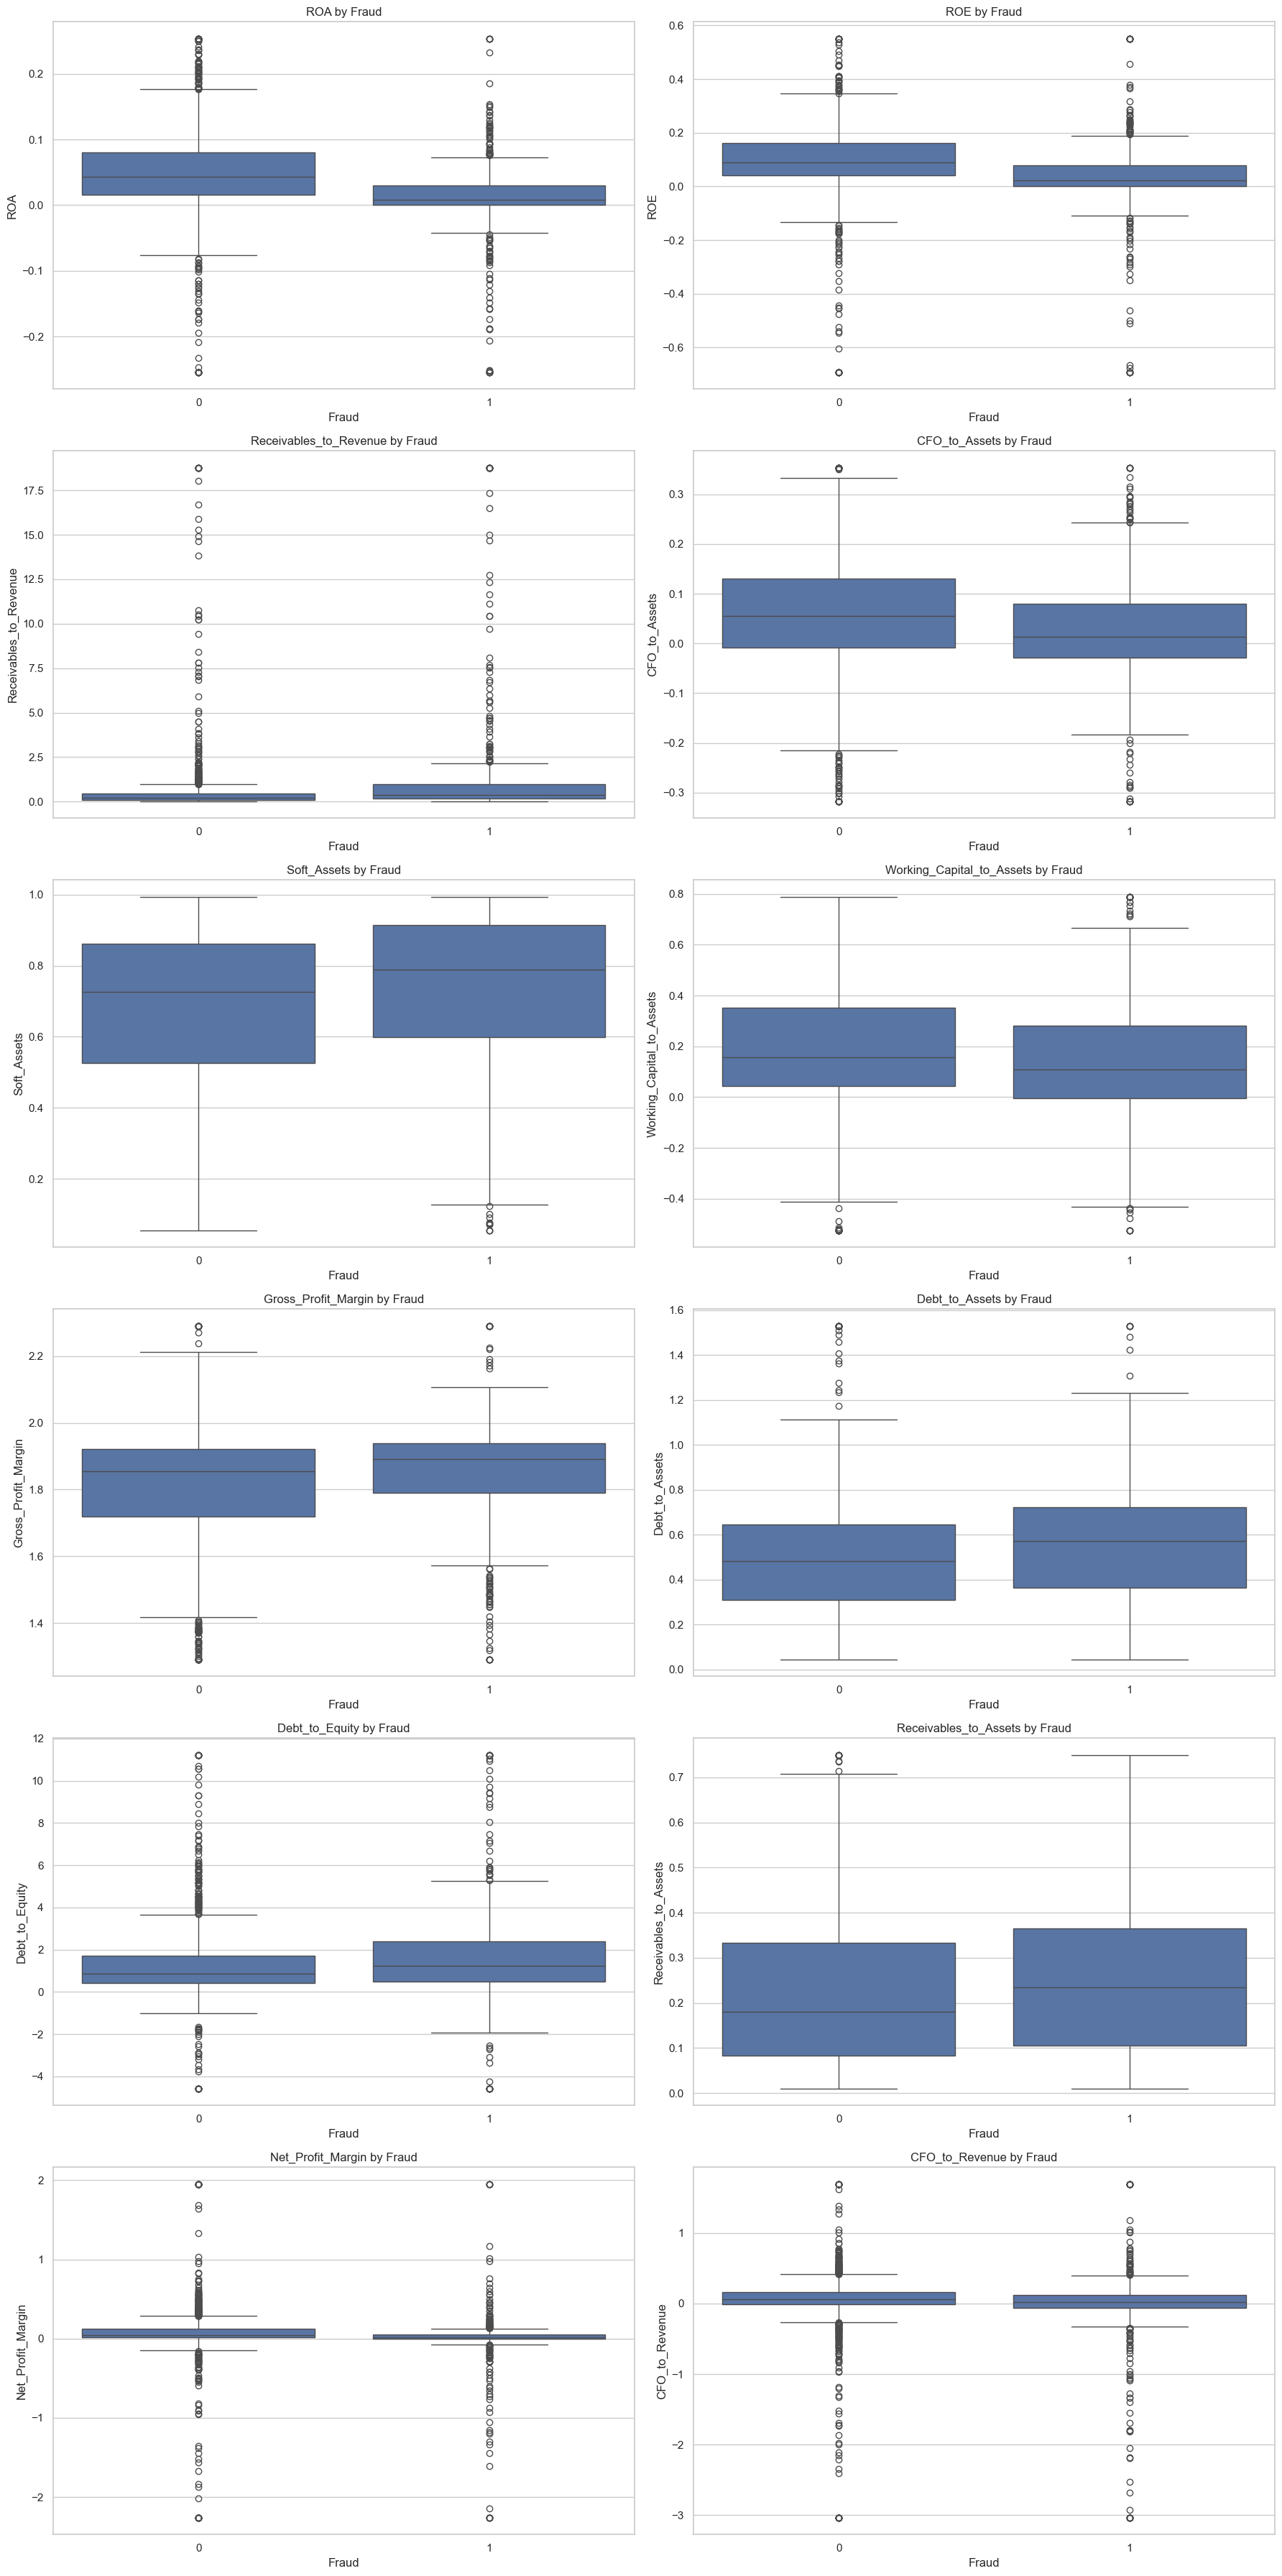

In [12]:
# =========================================================
# 6. BOXPLOT: GIAN LẬN VS KHÔNG GIAN LẬN
# =========================================================
top_n = 12

top_features = (
    corr_with_fraud.abs()
    .sort_values(ascending=False)
    .head(top_n)
    .index
    .tolist()
)

print("Top features by absolute correlation with Fraud:")
print(top_features)

n_cols = 2
n_rows = int(np.ceil(len(top_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(
        data=df,
        x="Fraud",
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} by Fraud")
    axes[i].set_xlabel("Fraud")
    axes[i].set_ylabel(col)

# xóa subplot thừa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Key Observations

From the comparison between fraud and non-fraud firms, several patterns emerge:

- **Lower profitability:** Fraud firms tend to exhibit lower **ROA** and **ROE**, indicating weaker financial performance.
- **Weaker cash flow quality:** Ratios such as **CFO_to_Assets** and **CFO_to_Revenue** are generally lower among fraud firms.
- **Higher receivables:** Fraud cases show higher **Receivables_to_Revenue** and **Receivables_to_Assets**, which may indicate aggressive revenue recognition.
- **Higher leverage:** Fraud firms tend to have slightly higher **Debt_to_Assets** and **Debt_to_Equity**, suggesting greater financial pressure.
- **More soft assets:** The **Soft_Assets** ratio is typically higher for fraud firms, reflecting assets that may be more difficult to verify.

These patterns suggest that fraudulent firms often combine weaker profitability, poorer cash flow quality, and higher financial pressure.